In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout


import torchvision as tv

from scripts.model_serialization import load_model

no_grad_guard = torch.no_grad()

2025-03-31 10:24:19.247958: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-31 10:24:19.255916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743409459.264458 1534778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743409459.267235 1534778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743409459.274402 1534778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
###############################################
# This configures which model/dataset we are evaluating
# Identity
model_path = PROJECT_ROOT / "models/identity/vit_good_freeze_embeddings/config.json"
ds_zoo_elephants = fo.load_dataset("zoo-elephants-identity-val")
# Behaviour
# model_path = PROJECT_ROOT / "models/sleep/vit/first/config.ptc"
# ds_zoo_elephants = fo.load_dataset("zoo-elephants-sleep-val")

###############################################

classes = sorted(ds_zoo_elephants.classes["ground_truth"])
print(classes)

['01_Chandra', '02_Indi', '03_Fahra', '04_Panang', '05_Thai']


In [3]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
model = load_model(model_path).to(torch.device("cuda"))
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [4]:
import PIL

import transformers

image_processor = transformers.AutoImageProcessor.from_pretrained(model_path.parent)


def transform_and_preprocess(image: PIL.Image):
    image = np.asarray(image)
    # image = tv.transforms.Resize([224,224])(image)
    image = image_processor.preprocess(image)["pixel_values"][0]
    image = torch.from_numpy(image)
    # image = image.permute([2,0,1])
    # raise RuntimeError(f"{type(image)}")
    # raise RuntimeError(f"type is {type(image)}, {str(image.shape)=}")
    return image


sample0 = next(ds_zoo_elephants.iter_samples())
im0 = PIL.Image.open(sample0["filepath"])
print(f"{transform_and_preprocess(im0).shape=}")
t0 = transform_and_preprocess(im0).unsqueeze(0).to(torch.device("cuda"))
r0 = model(t0)
print(f"{r0=}")
print(r0["logits"].shape)

transform_and_preprocess(im0).shape=torch.Size([3, 224, 224])
r0=ImageClassifierOutput(loss=None, logits=tensor([[ 6.8774, -3.5051,  0.4932,  0.3588, -2.7743]], device='cuda:0',
       grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
torch.Size([1, 5])


In [5]:
config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying model to samples...")
# ds_zoo_elephants.apply_model(fo_model, label_field="zoo_identity")
# predictions_view = ds_zoo_elephants.take(100, seed=51)
predictions_view = ds_zoo_elephants
predictions_view.apply_model(fo_model, label_field="prediction")
# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)

# session.view = predictions_view

Applying model to samples...
 100% |█████████████████| 187/187 [1.5s elapsed, 0s remaining, 147.5 samples/s]         


In [6]:
ds_zoo_elephants.delete_evaluations()
results = ds_zoo_elephants.evaluate_classifications(
    pred_field="prediction",
    gt_field="ground_truth",
    eval_key="eval",
    method="simple",
    classes=classes,
)

In [7]:
gt_counts = dict(sorted(predictions_view.count_values("ground_truth.label").items()))
pd_counts = dict(sorted(predictions_view.count_values("prediction.label").items()))
print(gt_counts)
print(pd_counts)
results.print_report()
# ds_zoo_elephants.iter_samples().__next__().get_field("ground_truth").get_field("label")

{'01_Chandra': 22, '02_Indi': 25, '03_Fahra': 46, '04_Panang': 46, '05_Thai': 48}
{'01_Chandra': 28, '02_Indi': 42, '03_Fahra': 28, '04_Panang': 33, '05_Thai': 56}
              precision    recall  f1-score   support

  01_Chandra       0.61      0.77      0.68        22
     02_Indi       0.50      0.84      0.63        25
    03_Fahra       0.82      0.50      0.62        46
   04_Panang       1.00      0.72      0.84        46
     05_Thai       0.84      0.98      0.90        48

    accuracy                           0.75       187
   macro avg       0.75      0.76      0.73       187
weighted avg       0.80      0.75      0.75       187



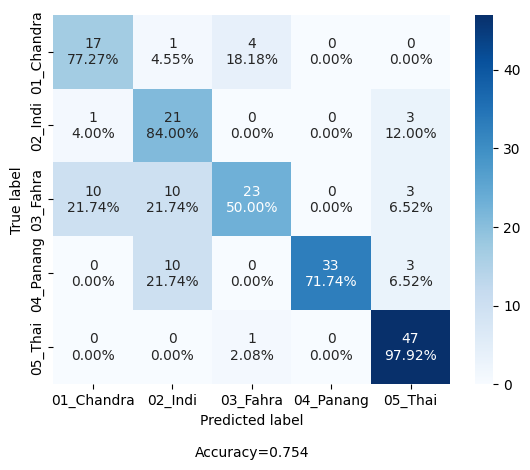

In [8]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

m = results.confusion_matrix()
# sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
make_confusion_matrix(m, categories=classes)

In [9]:
session = fo.launch_app(ds_zoo_elephants, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

In [10]:
from fiftyone import ViewField as F

session.view = (
    ds_zoo_elephants
    # .match_tags("validation")
    .match(F("prediction.label") != F("ground_truth.label"))
    # .sort_by("uniqueness", reverse=True)
)